In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import plotly.express as px
import sys
import os
sys.path.append(os.path.abspath("../"))



In [2]:
# Enable inline plotting
%matplotlib inline

In [3]:
df = pd.read_csv("../data/bank-additional-full.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Check for missing values
df.isnull().sum()

# Encode target variable
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Convert categorical features using one-hot encoding
df_encoded = pd.get_dummies(df.drop('y', axis=1), drop_first=True)

# Combine with target
X = df_encoded
y = df['y']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.65      0.54      0.59       935

    accuracy                           0.92      8238
   macro avg       0.80      0.75      0.77      8238
weighted avg       0.91      0.92      0.91      8238

Confusion Matrix:



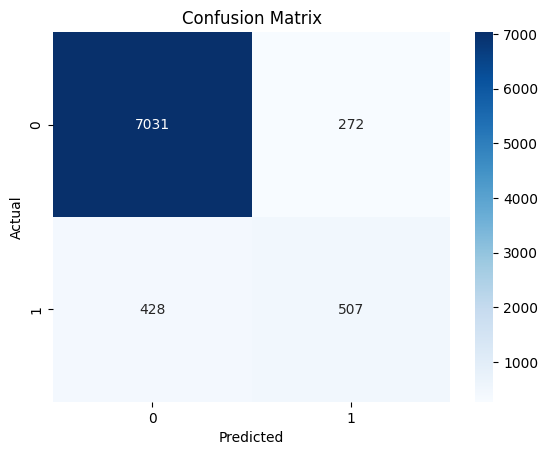

In [7]:
y_pred = clf.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


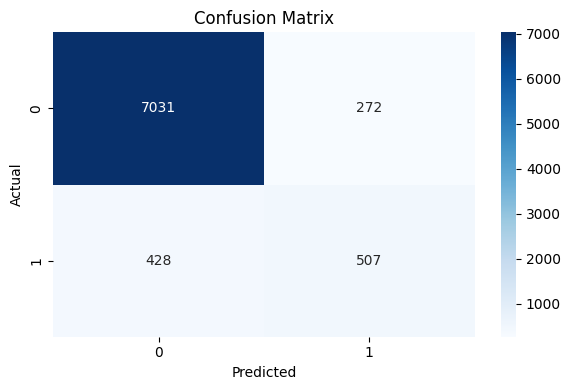

In [10]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix.png")
plt.show()


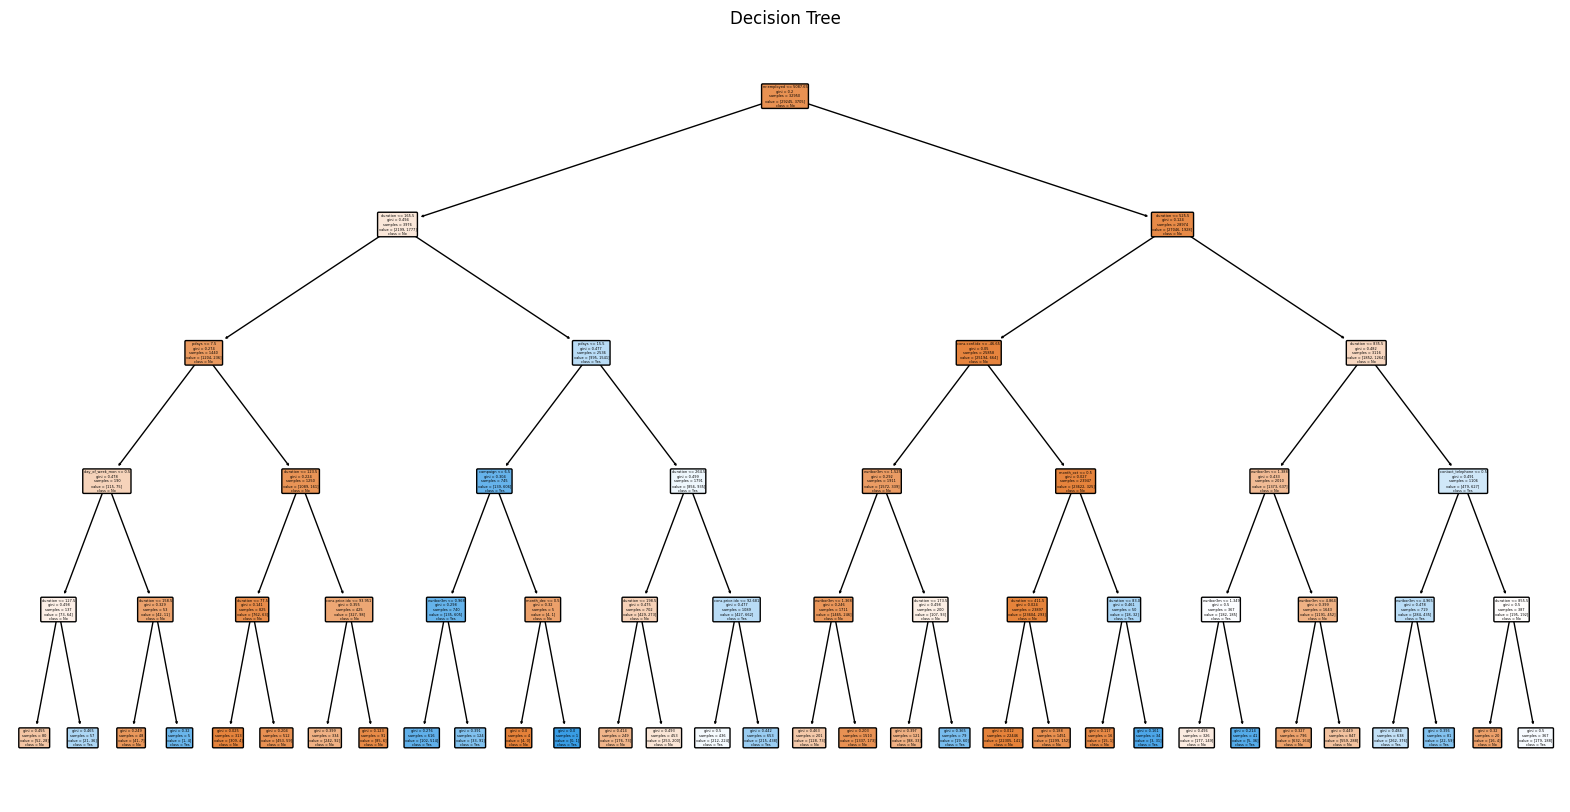

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True)
plt.title("Decision Tree")
plt.savefig("../outputs/figures/decision_tree.png")
plt.show()


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.65      0.54      0.59       935

    accuracy                           0.92      8238
   macro avg       0.80      0.75      0.77      8238
weighted avg       0.91      0.92      0.91      8238



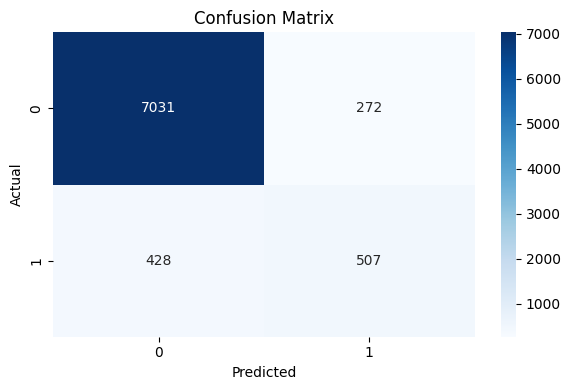

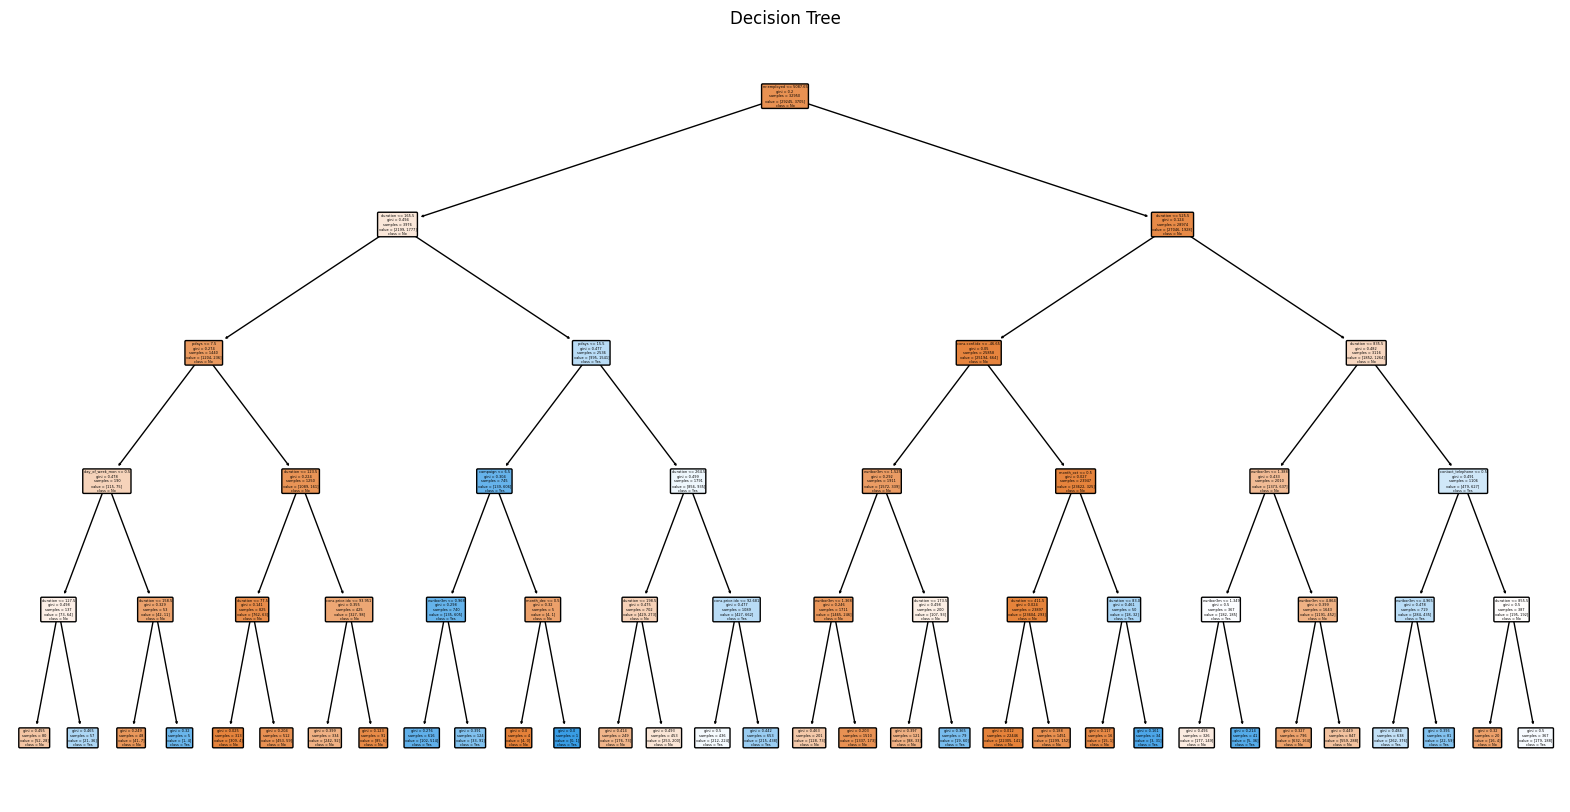

In [15]:
from src.preprocessing import load_data, preprocess_data, split_data
from src.modeling import train_model, evaluate_model

# Load and prepare data
df = load_data("../data/bank-additional-full.csv")
X, y = preprocess_data(df)
X_train, X_test, y_train, y_test = split_data(X, y)

# Train and evaluate
clf = train_model(X_train, y_train)
evaluate_model(clf, X_test, y_test)


In [2]:
# Split the single column into multiple columns using the delimiter ','
df_cleaned = df.iloc[:, 0].str.split(',', expand=True)

# Assign proper column names (based on the original dataset structure)
df_cleaned.columns = [
    'age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 
    'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar', 'job_entrepreneur', 
    'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 
    'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 
    'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 
    'education_high.school', 'education_illiterate', 'education_professional.course', 
    'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 
    'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 
    'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 
    'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 
    'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'y'
]

# Convert appropriate columns to numeric types
numeric_columns = [
    'age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 
    'cons.conf.idx', 'euribor3m', 'nr.employed'
]
df_cleaned[numeric_columns] = df_cleaned[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Save the cleaned data to a new CSV file
output_path = "../data/processed_bank_additional_full.csv"
df_cleaned.to_csv(output_path, index=False)

print(f"Cleaned data saved to {output_path}")

Cleaned data saved to ../data/processed_bank_additional_full.csv
